In [2]:
import pandas as Dimen_ReductPn
import warnings as Dimen_ReductWn
Dimen_ReductWn.filterwarnings("ignore")
import seaborn as Dimen_ReductSn
import matplotlib.pyplot as Dimen_ReductMn
import numpy as Dimen_ReductNn
from sklearn.preprocessing import LabelEncoder as Dimen_ReductEn

In [3]:
## Loading Large Scale Data ---##
Dimen_Reduct = Dimen_ReductPn.read_json('News_Category_Dataset_v2.json',lines=True)
Dimen_Reduct

,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26
...,...,...,...,...,...,...
200848,TECH,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,"Reuters, Reuters",https://www.huffingtonpost.com/entry/rim-ceo-t...,Verizon Wireless and AT&T are already promotin...,2012-01-28
200849,SPORTS,Maria Sharapova Stunned By Victoria Azarenka I...,,https://www.huffingtonpost.com/entry/maria-sha...,"Afterward, Azarenka, more effusive with the pr...",2012-01-28
200850,SPORTS,"Giants Over Patriots, Jets Over Colts Among M...",,https://www.huffingtonpost.com/entry/super-bow...,"Leading up to Super Bowl XLVI, the most talked...",2012-01-28
200851,SPORTS,Aldon Smith Arrested: 49ers Linebacker Busted ...,,https://www.huffingtonpost.com/entry/aldon-smi...,CORRECTION: An earlier version of this story i...,2012-01-28


In [4]:
Dimen_Reduct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   category           200853 non-null  object        
 1   headline           200853 non-null  object        
 2   authors            200853 non-null  object        
 3   link               200853 non-null  object        
 4   short_description  200853 non-null  object        
 5   date               200853 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.2+ MB


In [5]:
Dimen_Reduct.columns    #### features in the dataset ====

Index(['category', 'headline', 'authors', 'link', 'short_description', 'date'], dtype='object')

In [6]:
Dimen_Reduct.isna().sum().sum()   ##### find the missed values ====

0

In [7]:
Dimen_Reduct.duplicated().any()  ### find the duplicate rows ====

True

In [8]:
Dimen_Reduct.duplicated().sum()  ### find the total no.of duplicates ====

13

In [9]:
dupdim = Dimen_Reduct[Dimen_Reduct.duplicated()]  ### display the duplicate rows ====
dupdim

,category,headline,authors,link,short_description,date
59003,POLITICS,"On Facebook, Trump's Longtime Butler Calls For...",,https://www.huffingtonpost.comhttp://www.mothe...,"Anthony Senecal, who worked as Donald Trump's ...",2016-05-12
59249,TECH,Former Facebook Workers: We Routinely Suppress...,,https://www.huffingtonpost.comhttp://gizmodo.c...,Facebook workers routinely suppressed news sto...,2016-05-09
61565,WOMEN,"On Equal Pay Day, The Gap Is Still Too Wide",,https://www.huffingtonpost.comhttp://www.cnbc....,Equal Pay Day falls on April 12 in 2016. It's ...,2016-04-12
131156,WELLNESS,The World's Most Dangerous Workout?,,https://www.huffingtonpost.comhttp://www.cnn.c...,"Is the ""sport of fitness"" the world's most dan...",2014-02-10
135735,WELLNESS,Some People Call It 'The Best Anti-Smoking Ad ...,,https://www.huffingtonpost.comhttp://www.upwor...,Almost all smokers know cigarettes are bad for...,2013-12-22
136468,ENVIRONMENT,10 Cities That Could Run Out Of Water - Weathe...,,https://www.huffingtonpost.comhttp://www.weath...,"Securing access to plentiful, renewable source...",2013-12-15
169481,TECH,Google Is Attacking Apple From The Inside Out ...,,https://www.huffingtonpost.comhttp://www.busin...,After years of hammering away at Apple's share...,2013-01-01
178655,WELLNESS,"Eating For Health, Not Weight",,https://www.huffingtonpost.comhttp://www.nytim...,Almost half of Americans are on a diet -- not ...,2012-09-23
185922,TECH,Apple Removes Green EPEAT Electronics Certific...,,https://www.huffingtonpost.comhttp://blogs.wsj...,Apple has pulled its products off the U.S. gov...,2012-07-07
185924,TECH,Microsoft's $6.2 Billion Writedown Shows It's ...,,https://www.huffingtonpost.comhttp://www.theda...,Fighting for online advertising dominance with...,2012-07-07


In [10]:
Dimen_Reduct = Dimen_Reduct.drop_duplicates()  #### Deleting duplicate rows ===
Dimen_Reduct.shape

(200840, 6)

In [11]:
del Dimen_Reduct['date'] ### deleting unwanted feature ===

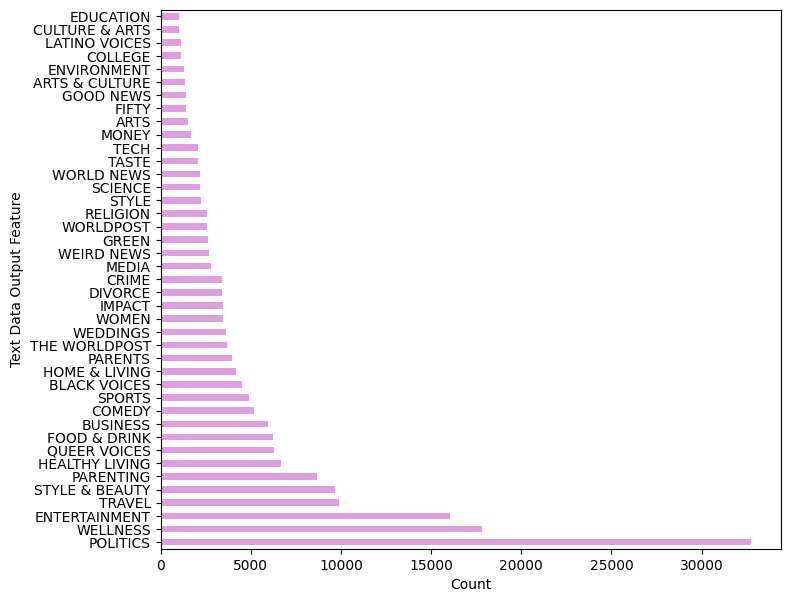

In [12]:
### Visualizing through bar plot =====
Dimen_ReductMn.figure(figsize=(8,7))
Dimen_Reduct['category'].value_counts().plot(kind='barh', color='plum')
Dimen_ReductMn.xlabel('Count')
Dimen_ReductMn.ylabel('Text Data Output Feature')
Dimen_ReductMn.show()

In [13]:
#### taking 2 main columns for the research =====
Dimen_Reduct = Dimen_Reduct[['short_description','category']]
Dimen_Reduct

,short_description,category
0,She left her husband. He killed their children...,CRIME
1,Of course it has a song.,ENTERTAINMENT
2,The actor and his longtime girlfriend Anna Ebe...,ENTERTAINMENT
3,The actor gives Dems an ass-kicking for not fi...,ENTERTAINMENT
4,"The ""Dietland"" actress said using the bags is ...",ENTERTAINMENT
...,...,...
200848,Verizon Wireless and AT&T are already promotin...,TECH
200849,"Afterward, Azarenka, more effusive with the pr...",SPORTS
200850,"Leading up to Super Bowl XLVI, the most talked...",SPORTS
200851,CORRECTION: An earlier version of this story i...,SPORTS


In [14]:
##### Text Preprocessing =======
import regex as Dimen_ReductRxx
import nltk as Dimen_ReductNlk
Dimen_ReductNlk.download('stopwords')
from nltk.corpus import stopwords as FNSWRD

dimWd = FNSWRD.words('english')

def reduct(proword):
    dimR = proword.lower()  #### convert 'short_description' text to lowercase ======
    dimR = Dimen_ReductRxx.sub("[^a-z]+", " ", dimR)  #### drop non-alphabetic characters ======
    dimR = " ".join([d for d in dimR.split() if d not in dimWd])  #### split long text into words =====
    return dimR

dimReduct = []  ####=== Empty list to store the processed text =====
for r in Dimen_Reduct['short_description']:
    dimReduct.append(reduct(r))
Dimen_Reduct['short_description'] = dimReduct

Dimen_Reduct.to_csv('TextData_DimensionalityReduction.csv', index=False)
Dimen_Reduct

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,short_description,category
0,left husband killed children another day america,CRIME
1,course song,ENTERTAINMENT
2,actor longtime girlfriend anna eberstein tied ...,ENTERTAINMENT
3,actor gives dems ass kicking fighting hard eno...,ENTERTAINMENT
4,dietland actress said using bags really cathar...,ENTERTAINMENT
...,...,...
200848,verizon wireless already promoting lte devices...,TECH
200849,afterward azarenka effusive press normal credi...,SPORTS
200850,leading super bowl xlvi talked game could end ...,SPORTS
200851,correction earlier version story incorrectly s...,SPORTS
